<center><p float="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/e/e9/4_RGB_McCombs_School_Brand_Branded.png" width="300"/>
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200"/>
</p></center>


<center><font size=10>AI Agents and Generative AI for Business Applications</center></font>
<center><font size=6>Single Agent System</center></font>

<center><p float="center">
  <img src="https://images.pexels.com/photos/5971243/pexels-photo-5971243.jpeg" width="640"/>
</p></center>

<center><font size=6>Reimbursement Automation
</center></font>

## **Problem Statement**

### Business Context

In many mid-sized and large organizations, **employee expense processing and reimbursement** continues to rely heavily on manual, paper-based workflows. Employees submit physical or scanned receipts, which finance teams must individually review, categorize, and validate against company expense policies. This process demands significant time and effort to verify expense details such as category, amount, date, vendor, and compliance requirements.

As organizations grow, the **volume of expense claims increases substantially**, placing additional strain on finance teams. Manual processing creates operational bottlenecks, slows reimbursement cycles, and raises processing costs. It also increases the likelihood of human errors, duplicate reimbursements, and policy violations. Delays in reimbursements can negatively affect employee satisfaction and erode confidence in internal financial processes.

Additionally, expense policy interpretation often varies across reviewers, leading to **inconsistent approval decisions** and increased audit and compliance risks. The lack of automation limits real-time visibility into organizational spending patterns, making it difficult for finance teams to proactively enforce controls, detect anomalies, or identify potential misuse early in the process.



### Objective



The objective is to simplify and streamline the expense processing and reimbursement workflow by leveraging intelligent automation. Routine tasks such as receipt data extraction, expense categorization, and policy validation can be handled automatically, reducing manual effort and processing time.

* Reduce manual effort in reviewing and processing expense claims
* Minimize errors and policy non-compliance in reimbursements
* Accelerate reimbursement turnaround time for employees

### Data Description


This dataset is a structured reimbursement database containing employee, reimbursement history, and policy information.

**Reimbursement Database Tables**

1. **Employee Details Table** - Employee ID, Name, Position
2. **Past Reimbursements Table** - ID, Employee ID, Reimbursement Date, Category, Amount
3. **Reimbursement Policy Table** - Position, Category, Reimbursement Amount (max allowable)

## **Solution Approach**



The notebook implements a single agent using LangGraph's prebuilt `create_agent`, where a single intelligent agent processes an employee reimbursement request by interleaving reasoning with specialized tool calls instead of following a hardcoded execution pipeline. Rather than embedding business logic directly inside the language model, the agent dynamically decides which tool to invoke next, observes the result, and continues reasoning until the reimbursement request has been completely processed.

#### Architecture Components

* **Receipt OCR Tool** - Extracts raw text from the uploaded receipt image using a multimodal LLM, preserving the original bill contents as the single source of truth for all downstream processing.

* **Bill Structuring Tool** - Converts the unstructured OCR output into a standardized JSON representation containing transaction metadata and category-wise expense amounts required for reimbursement processing.

* **Bill Validation Tool** - Audits the structured bill against the original receipt, verifying arithmetic consistency, tax inclusion, category allocation, and overall data integrity before any financial decision is made.

* **Bill Re-Structuring Tool** - Activated only when validation fails; repairs the structured bill using the original receipt and the validation rationale, then returns the corrected output for re-validation until a valid expense structure is obtained.

* **Policy Retrieval Tools** - Retrieve reimbursement limits and the employee's historical reimbursement utilization from the enterprise database through MCP-enabled SQL tools, ensuring all reimbursement decisions are based on current organizational policies.

* **Reimbursement Calculation Tool** - Deterministically computes the approved reimbursement for each expense category by applying policy limits and previous utilization, ensuring approved amounts never exceed the employee's remaining eligibility.

* **Decision Email Generation Tool** - Produces a professional, audit-ready reimbursement decision email summarizing the approved reimbursement amounts together with the policy-based rationale behind the decision.

* **Email Dispatch Tool** - Sends the finalized reimbursement decision through an MCP-managed email service, allowing the agent to perform real-world actions without requiring direct access to external systems.

This architecture closely mirrors how an experienced finance reviewer processes reimbursement requests: extract receipt information, organize the expense details, verify correctness, correct inconsistencies when necessary, apply reimbursement policies, calculate the approved amounts, communicate the decision, and finally notify the employee. By separating reasoning from external actions through MCP tools and combining iterative validation with deterministic reimbursement calculations, the workflow produces transparent, auditable, and policy-compliant reimbursement decisions while remaining easy to extend with additional enterprise business tools in the future.


### Flow Diagram

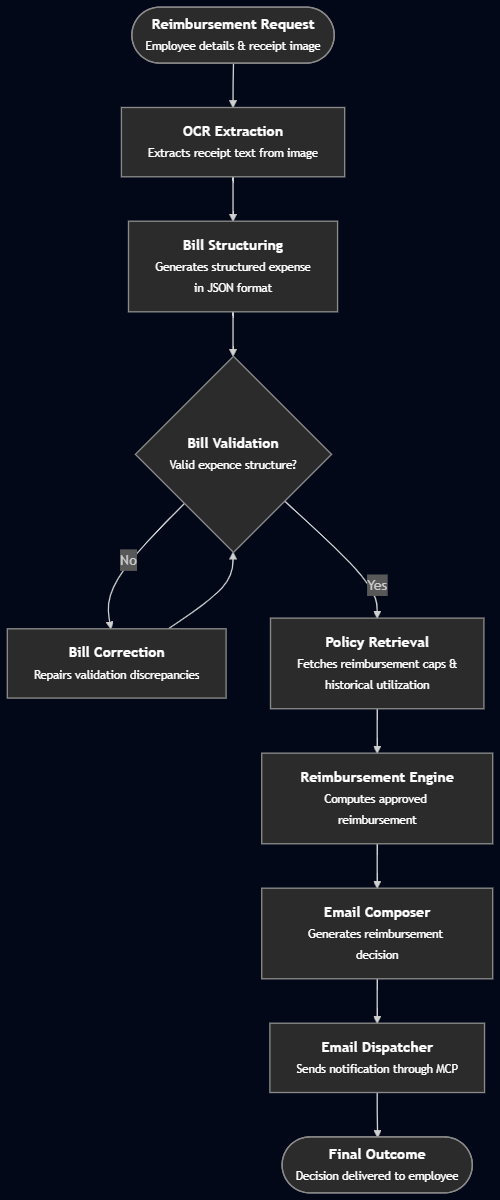

## **Installing and Importing Necessary Libraries and Dependencies**

In [1]:
# !pip install -qU \
#       langchain==1.3.9 \
#       langchain-ollama==1.0.1 \
#       langchain-community==0.4.2 \
#       langgraph==1.2.5 \
#       fastmcp==2.12.4 \
#       mcp==1.23.0 \
#       nest_asyncio==1.6.0 \
#       2>/dev/null

# This notebook runs against a local Ollama server. Install Ollama and pull both
# the reasoning model and a vision-capable model before running the notebook:
#       ollama pull qwen3:8b        # main agent (text, tool-calling)
#       ollama pull gemma4:latest   # vision model for reading bill images

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

In [2]:
import os
import json
import re
import time
import pandas as pd
import threading
import sqlite3
import asyncio
from typing import Annotated
import base64
import mimetypes
# from google.colab import files

import nest_asyncio
nest_asyncio.apply()

from langchain_ollama import ChatOllama
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, SystemMessage

from langchain_community.utilities import SQLDatabase
from langchain_community.agent_toolkits import SQLDatabaseToolkit

# Corrected import for LangGraph's prebuilt agent
from langchain.agents import create_agent

from fastmcp import FastMCP
import smtplib
from email.mime.text import MIMEText
from email.mime.multipart import MIMEMultipart

from mcp import ClientSession
from mcp.client.streamable_http import streamablehttp_client as streamable_http_client

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning, module="jupyter_client")

/home/z187900/courses/AI_Agents_for_Business_Applications_UT_Austin/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/z187900/courses/AI_Agents_for_Business_Applications_UT_Austin/.venv/lib/python3.11/site-packages/fastmcp/server/auth/providers/jwt.py:10: AuthlibDeprecationWarning: authlib.jose module is deprecated, please use joserfc instead.
It will be compatible before version 2.0.0.
  from authlib.jose import JsonWebKey, JsonWebToken


## **Setting Up Email Credentials and SMTP Configuration**

As part of the reimbursement workflow, the system must notify employees about the outcome of their reimbursement requests, which requires controlled access to an email service for sending notifications.


To enable automated reimbursement notifications, the system needs permission to send emails on behalf of a sender account. This can be achieved using **SMTP credentials**, which allow the application to authenticate with an email service and deliver messages securely.


Instead of hardcoding credentials inside the logic, we externalize all email-related settings into a
configuration file. This makes the notebook:

- Safer (credentials are not scattered in code)
- Easier to maintain
- Portable across email providers (Gmail, Outlook, Zoho, corporate SMTP)

We use an **App Password** instead of a login password to ensure restricted, audit-safe access.


### Generating an App Password (Gmail)

Most email providers do not allow direct login passwords to be used for automated access. Instead, they require an **App Password**, which is a restricted credential specifically designed for programmatic email access.

For Gmail accounts:
1. Enable **2-Step Verification** in your Google account.
2. Navigate to **App Passwords** under Security settings.
3. Create a new app password for *Mail*.
4. Use the generated password for SMTP authentication.

This approach limits access to email functionality only and improves overall security.


**NOTE:** While the steps above are shown for Gmail, most other email providers (such as Outlook, Zoho, and Rediffmail) follow a similar approach and require app-specific or service-specific passwords for secure SMTP access.

### Storing Email Credentials

Only sensitive credentials required for authentication are stored in the configuration file. These include:

* The sender email address
* The app password associated with that email account

The language model runs locally through Ollama, so no LLM API key is required. Optionally, an `OLLAMA_BASE_URL` can be added to point at a remote Ollama server.

```
{
  "SENDER_EMAIL": "your-email-id",
  "GMAIL_APP_PASSWORD": "your-app-password",

  "OLLAMA_BASE_URL": "http://localhost:11434"
}
```

### SMTP Host and Port Configuration

SMTP host and port define the **email service responsible for delivering messages** from the system.  
These settings must match the provider of the sender email account.

If the sender email belongs to a different service, the SMTP host and port must be updated accordingly to ensure successful authentication and email delivery.


Below are commonly used SMTP configurations. Select the configuration that matches the sender email service.

| Email Provider        | SMTP Host              | Port | Encryption |
|----------------------|------------------------|------|------------|
| Gmail                | smtp.gmail.com         | 465  | SSL        |
| Gmail (STARTTLS)     | smtp.gmail.com         | 587  | STARTTLS  |
| Outlook / Office365  | smtp.office365.com     | 587  | STARTTLS  |
| Yahoo Mail           | smtp.mail.yahoo.com    | 465  | SSL        |
| Zoho Mail            | smtp.zoho.com          | 465  | SSL        |
| Corporate Email      | Provided by IT Team    | Varies | Varies |


In this case study, we use a **Gmail sender account authenticated via an App Password**.  
Accordingly, the SMTP host and port are configured for **Gmail’s SMTP service**.

In [3]:
port=465

SMTP_host='smtp.gmail.com'

Email delivery relies on two things:
1. Valid authentication credentials (sender email and app password)
2. Correct SMTP host and port for the email provider

As long as both are correctly configured, the system can send audit-safe, automated notifications without any changes to the core workflow logic.


## **Model Initialization**


### Ollama Models (qwen3:8b + gemma4:latest for vision)

In [4]:
# Load the JSON file and extract values
file_name = '../../../../config.json'                                          # Name of the configuration file
with open(file_name, 'r') as file:                                             # Open the config file in read mode
    config = json.load(file)                                                   # Load the JSON content as a dictionary
    GMAIL_APP_PASSWORD = config.get("GMAIL_APP_PASSWORD")                      # Gmail app password for sending emails
    SENDER_EMAIL = config.get("SENDER_EMAIL")                                  # Sender email address

# Base URL of the local Ollama server (override in config.json if needed)
OLLAMA_BASE_URL = config.get("OLLAMA_BASE_URL", "http://localhost:11434")

In [ ]:

# Primary reasoning / tool-calling model used by the agent.
# NOTE: keep "thinking" ON here (no reasoning=False). Disabling it makes the
# model drop required multi-argument tool fields (e.g. validate_structured_bill's
# structured_bill_json), which makes the agent loop on tool errors.
llm = ChatOllama(
    model="gemma4:latest",
    temperature=0,
    base_url=OLLAMA_BASE_URL,
    keep_alive="30m",     # keep the model loaded in memory between tool calls
)

# Same multimodal model, used only for reading bill/receipt images (OCR).
vision_llm = ChatOllama(
    model="gemma4:latest",
    temperature=0,
    base_url=OLLAMA_BASE_URL,
    reasoning=False,      # OCR is a single call; no chain-of-thought needed
    keep_alive="30m",     # keep the vision model warm to avoid reloads
)

## **MCP Setup**

Next, we initialize the MCP instance, which will act as the central control layer for this notebook exposing business tools (like SQL queries and email actions) and enabling structured, tool-based interactions over a controlled interface.


In [6]:
mcp = FastMCP("demo", host="127.0.0.1", port=8000)

/home/z187900/courses/AI_Agents_for_Business_Applications_UT_Austin/.venv/lib/python3.11/site-packages/fastmcp/server/server.py:285: DeprecationWarning: Providing `host` when creating a server is deprecated. Provide it when calling `run` or as a global setting instead.
  self._handle_deprecated_settings(
/home/z187900/courses/AI_Agents_for_Business_Applications_UT_Austin/.venv/lib/python3.11/site-packages/fastmcp/server/server.py:285: DeprecationWarning: Providing `port` when creating a server is deprecated. Provide it when calling `run` or as a global setting instead.
  self._handle_deprecated_settings(


### SQL MCP Tool

This tool allows MCP to execute SQL queries on the database in a controlled and structured way.


The `@mcp.tool` decorator registers this function as a callable MCP tool, making it safely accessible to the agent through the MCP server instead of allowing direct database access.

In [7]:
DB_PATH = "reimbursement.db"

In [8]:
@mcp.tool()
def run_sql(db_path: str, sql: str) -> str:
    """
    Execute SQL on sqlite db and return JSON:
      {"columns":[...], "rows":[...]}
    or {"error":"..."}.
    """
    try:
        # Establish a connection to the SQLite database
        conn = sqlite3.connect(db_path)
        cur = conn.cursor()

        # Execute the provided SQL query
        cur.execute(sql)

        # Handle read queries (SELECT / WITH)
        if sql.strip().lower().startswith(("select", "with")):
            rows = cur.fetchall()
            cols = [d[0] for d in cur.description] if cur.description else []
            conn.close()
            return json.dumps({"columns": cols, "rows": rows})
        else:
            # Handle write operations (INSERT / UPDATE / DELETE)
            conn.commit()
            conn.close()
            return json.dumps({"status": "ok"})

    except Exception as e:
        # Return any execution error in a structured format
        return json.dumps({"error": str(e)})

### EMAIL MCP Tool

This tool enables MCP to send emails programmatically, allowing the system to trigger real-world notifications and actions as part of an automated workflow.


In [9]:
@mcp.tool()
def send_email(
    sender_email: str,
    app_password: str,
    receiver_email: str,
    subject: str,
    body: str
) -> str:
    """
    Sends an email using Gmail SMTP.

    This MCP tool is responsible for delivering the final reimbursement
    decision email. It authenticates using the sender's email address
    and a Gmail App Password, then sends the message securely over SSL.

    Returns:
    - {"status": "sent"} on successful delivery
    - {"error": "<message>"} if email sending fails
    """
    # Log the recipient for traceability during execution
    print(f"[INSIDE TOOL]: send_email to={receiver_email}")

    try:
        # Create the email container
        msg = MIMEMultipart()
        msg["From"] = sender_email          # Sender email address
        msg["To"] = receiver_email          # Recipient email address
        msg["Subject"] = subject             # Email subject line

        # Attach the email body as plain text
        msg.attach(MIMEText(body, "plain"))

        # Establish a secure SSL connection to the SMTP server
        # SMTP_host and port are configured earlier for Gmail
        with smtplib.SMTP_SSL(SMTP_host, port) as server:

            # Authenticate using the app password (not the login password)
            server.login(sender_email, app_password)

            # Send the composed email message
            server.send_message(msg)

        # Return a structured success response
        return json.dumps({"status": "sent"})

    except Exception as e:
        # Catch and return any SMTP or authentication errors
        return json.dumps({"error": str(e)})

## **Starting the MCP Server: Making Tools Callable**

Before our system can run SQL queries or send emails, we need a central service that exposes these capabilities in a structured and controlled way.
This is where the MCP (Model Context Protocol) server comes in.

Think of the MCP server as:

- A tool hub that hosts business capabilities (SQL, email, etc.)

- A bridge between our notebook (or an AI agent) and real-world actions

- A controlled execution layer, instead of running arbitrary code directly

To keep the notebook interactive, we start the MCP server in the background.

### Starting the MCP Server in a Background Thread

Here, we configure MCP to run over streamable HTTP, which is required for:

- Long-lived connections

- Tool calls with structured responses

- Two-way communication between client and server

In [10]:
def start_mcp_server():
    """
    Starts the MCP server using streamable HTTP transport.

    streamable-http allows the MCP server to:
    - Accept HTTP-based streaming connections
    - Support bidirectional communication (read/write streams)
    """
    mcp.run(transport="streamable-http")

We run the server in a daemon thread so:

- The notebook does not freeze

- The server shuts down automatically when the notebook stops

- We can continue executing client-side code in later cells

In [11]:
# Start the MCP server in a background thread so that
# it does not block the Jupyter notebook execution
server_thread = threading.Thread(
    target=start_mcp_server,
    daemon=True  # Daemon thread exits automatically with the main program
)

server_thread.start()

# Give the server a moment to initialize
time.sleep(2)

print("MCP server started on http://127.0.0.1:8000/mcp")


╭──────────────────────────────────────────────────────────────────────────────╮                  
                 │                                                                              │                  
                 │                                                                              │                  
                 │                         ▄▀▀ ▄▀█ █▀▀ ▀█▀ █▀▄▀█ █▀▀ █▀█                        │                  
                 │                         █▀  █▀█ ▄▄█  █  █ ▀ █ █▄▄ █▀▀                        │                  
                 │                                                                              │                  
                 │                                                                              │                  
                 │                                                                              │                  
                 │                                FastMCP 2.14.4                                │                  
                 │                            https://gofastmcp.com                             │                  
                 │                                                                              │                  
                 │                    🖥  Server:      demo                                      │                  
                 │                    🚀 Deploy free: https://fastmcp.cloud                     │                  
                 │                                                                              │                  
                 ╰──────────────────────────────────────────────────────────────────────────────╯                  
                 ╭──────────────────────────────────────────────────────────────────────────────╮                  
                 │                          ✨ FastMCP 3.0 is coming!                           │                  
                 │       Pin `fastmcp < 3` in production, then upgrade when you're ready.       │                  
                 ╰──────────────────────────────────────────────────────────────────────────────╯                  
                 ╭──────────────────────────────────────────────────────────────────────────────╮                  
                 │                          🎉 Update available: 3.4.4                          │                  
                 │                      Run: pip install --upgrade fastmcp                      │                  
                 ╰──────────────────────────────────────────────────────────────────────────────╯

[07/27/26 15:19:47] INFO     Starting MCP server 'demo' with transport 'streamable-http' on          ]8;id=15926730;file:///home/z187900/courses/AI_Agents_for_Business_Applications_UT_Austin/.venv/lib/python3.11/site-packages/fastmcp/server/server.py\server.py]8;;\:]8;id=15926731;file:///home/z187900/courses/AI_Agents_for_Business_Applications_UT_Austin/.venv/lib/python3.11/site-packages/fastmcp/server/server.py#2580\2580]8;;\
                             http://127.0.0.1:8000/mcp                                                             

INFO:     Started server process [177858]
INFO:     Waiting for application startup.
/home/z187900/courses/AI_Agents_for_Business_Applications_UT_Austin/.venv/lib/python3.11/site-packages/redis/asyncio/connection.py:1599: DeprecationWarning: FakeConnection is deprecated. Use FakeAsyncRedisConnection instead
  return self.connection_class(**self.connection_kwargs)
INFO:     Application startup complete.
INFO:     Uvicorn running on http://127.0.0.1:8000 (Press CTRL+C to quit)


MCP server started on http://127.0.0.1:8000/mcp


### Defining How the Client Connects to MCP

Now that the MCP server is running, the client needs to know where to find it.

In [12]:
# MCP server endpoint
MCP_URL = "http://127.0.0.1:8000/mcp"

This endpoint acts as the single entry point for all tool-based interactions that follow.

### Helper Function: Picking Read & Write Streams


When we connect to the MCP server using a streaming HTTP client, the connection returns multiple internal objects, not all of which are directly useful.

However, MCP communication fundamentally relies on:

- A write stream -> to send requests

- A read stream -> to receive responses

This helper function extracts the correct streams safely.

In [13]:
def _pick_streams(ctx_tuple):
    """
    streamable_http_client yields a tuple/list with multiple items.
    We pick:
      - write_stream: has .send
      - read_stream: has .receive
    """
    write_stream = None
    read_stream = None

    for obj in ctx_tuple:
        if write_stream is None and hasattr(obj, "send"):
            write_stream = obj
        if read_stream is None and hasattr(obj, "receive"):
            read_stream = obj

    if read_stream is None or write_stream is None:
        raise RuntimeError(
            "Could not find read/write streams in streamable_http_client context. "
            f"Got types: {[type(x) for x in ctx_tuple]}"
        )
    return read_stream, write_stream


This makes the connection logic explicit and robust, instead of relying on assumptions about object order.

### Core MCP Interaction Logic (Async)

This function is the **heart of our MCP-based system**. Its job is to take a tool name (for example, `run_sql` or `send_email`) along with input arguments, connect to the running MCP server, and execute that tool in a safe and structured way.

Conceptually, this function performs four key steps:

1. **Connect to the MCP server** using a streaming HTTP client.
2. **Establish a session** by identifying read/write streams and completing a protocol handshake.
3. **Invoke the requested tool** with the provided arguments.
4. **Parse and return the result** in a clean, predictable format (JSON when possible).

Because MCP communication is asynchronous and stream-based by design, this function is written as `async`. A synchronous wrapper is added later so notebook users can call tools without worrying about async details.


In [14]:
async def _mcp_tool_call_async(tool_name: str, args: dict) -> dict:
    # Step 1: Open a streaming HTTP connection to the MCP server
    async with streamable_http_client(MCP_URL) as ctx:

        # Ensure the client returns multiple stream-related objects
        # (MCP requires both a read stream and a write stream)
        if not isinstance(ctx, (tuple, list)):
            raise RuntimeError(
                f"Expected tuple/list from streamable_http_client, got {type(ctx)}"
            )

        # Step 2: Extract the correct read and write streams needed for communication
        read_stream, write_stream = _pick_streams(ctx)

        # Step 3: Create a client session using the extracted streams
        async with ClientSession(read_stream, write_stream) as session:

            # Initialize the session to complete the MCP handshake
            # and make registered tools available
            await session.initialize()

            # Step 4: Call the specified MCP tool with the provided arguments
            res = await session.call_tool(tool_name, args)

            # Step 5: Attempt to parse structured text output (usually JSON)
            if res.content and hasattr(res.content[0], "text"):
                txt = res.content[0].text
                try:
                    return json.loads(txt)
                except Exception:
                    # If parsing fails, return the raw text safely
                    return {"raw_text": txt}

            # Final fallback for unexpected response formats
            return {"raw": str(res)}


### Notebook-Safe Wrapper (Why This Exists)


Jupyter notebooks already run an event loop.
Calling async functions directly can cause errors like:

“RuntimeError: event loop is already running”

To avoid this, we expose a synchronous wrapper.

In [15]:
def mcp_tool_call(tool_name: str, args: dict) -> dict:
    # safe in notebooks because nest_asyncio.apply() is active
    return asyncio.run(_mcp_tool_call_async(tool_name, args))

This allows learners to call MCP tools like normal Python functions.

#### Tool Wrapper: Run SQL via MCP

Finally, we define task-specific helpers that hide protocol details and expose intent clearly.

In [16]:
def mcp_run_sql(sql: str) -> dict:
    return mcp_tool_call("run_sql", {"db_path": DB_PATH, "sql": sql})

#### Tool Wrapper: Send Email via MCP

This enables real-world actions while keeping credentials and execution logic outside the model.

In [17]:
def mcp_send_email(to_email: str, subject: str, body: str) -> dict:
    return mcp_tool_call(
        "send_email",
        {
            "sender_email": SENDER_EMAIL,
            "app_password": GMAIL_APP_PASSWORD,
            "receiver_email": to_email,
            "subject": subject,
            "body": body,
        },
    )

## **Agentic AI Implementation**

### Tool 1: Extract Bill from Image

***Prompt***:

<font size=3 color="#4682B4"><b> Create a tool that extracts raw text from a bill or receipt image using a multimodal LLM. Accept an image filename or path, encode the image as Base64, send it with OCR instructions, and return the transcribed text while preserving the original layout and formatting.
</font>

Before the agent can structure or validate anything, it needs the **raw text** of the bill.

This tool reads the image and asks a vision-capable Ollama model (`gemma4:latest`) to transcribe the receipt verbatim. It returns the raw OCR-style text, which the agent then feeds into `structure_bill` in the next step.

> **Note:** The main agent runs on `qwen3:8b`, which is text-only. Image transcription therefore uses a separate multimodal model (`vision_llm` = `gemma4:latest`).

In [18]:
import socket

def port_in_use(port, host="127.0.0.1"):
    with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
        return s.connect_ex((host, port)) == 0

if not port_in_use(8000):
    server_thread = threading.Thread(target=start_mcp_server, daemon=True)
    server_thread.start()
    time.sleep(2)
    print("MCP server started on http://127.0.0.1:8000/mcp")
else:
    print("MCP server already running on http://127.0.0.1:8000/mcp")

MCP server already running on http://127.0.0.1:8000/mcp


In [19]:
BILLS_FOLDER = "Bills"

@tool
def extract_bill_from_image(image: str) -> str:
    """
    Read a bill / receipt image from the local bills folder and return its
    raw text (OCR-style transcription) using the multimodal LLM.

    Use this tool FIRST, before structuring the bill. It converts the
    receipt image into the raw text that all downstream tools expect.

    Args:
        image: The bill image filename (e.g. "bill_001.png") located in the
               `bills/` folder. A full path is also accepted.

    Returns:
        A string containing the raw bill text transcribed from the image
        (line breaks, item rows, amounts, taxes - all preserved as-is).
    """
    image_value = str(image).strip()
    if os.path.isabs(image_value) or os.path.sep in image_value:
        image_path = image_value
    else:
        image_path = os.path.join(BILLS_FOLDER, image_value)

    mime, _ = mimetypes.guess_type(image_path)
    if mime is None:
        mime = "image/png"

    with open(image_path, "rb") as f:
        b64 = base64.b64encode(f.read()).decode("utf-8")
    data_url = f"data:{mime};base64,{b64}"

    ocr_prompt = (
        "You are an OCR engine. Extract ALL the text visible in this bill / "
        "receipt image, preserving the original layout, line breaks, item rows, "
        "and numbers exactly as they appear. Do not summarize, do not add "
        "commentary, do not wrap in code fences. Return only the raw "
        "transcribed text of the bill."
    )

    message = HumanMessage(
        content=[
            {"type": "text", "text": ocr_prompt},
            {"type": "image_url", "image_url": {"url": data_url}},
        ]
    )
    # Use the vision-capable model (gemma4:latest) for image transcription.
    response = vision_llm.invoke([message])
    return response.content


In [20]:
extract_bill_from_image.invoke("TC 1 Amit Sharma.png")

'"THE OAK STREET BISTRO\n245 Oak Street, San Francisco, CA 94102\nPhone No: (415) 555-2389\nLiquor License No: CA-LL-558912\nSales Tax ID: CA-ST-784512\n\nRESTAURANT\nBill No: SF10983\nDate: 14/01/26\nTime: 19:45\nTable: 12\nCover: 2\nServer: Emily\nPOS ID: eml_07\n\nItem Details\nItem Name Qty Rate (USD) Amount\nLiquor - Classic Margarita 2 14.00 28.00\nLiquor - Napa Valley Cabernet 1 18.00 18.00\nCaesar Salad 1 12.00 12.00\nGrilled Salmon 1 26.00 26.00\nTruffle Fries 1 9.00 9.00\n\nSub Total (5 items): 93.00\nLiquor Tax 6%: 2.76\nService Charge 8%: 7.44\nSales Tax 8.625%: 6.93\n\nGross Amount: 110.13\n\nOrder No: ORD-SF-77822\nTHANK YOU FOR DINING WITH US"'

### Tool 2: Structure a Raw Bill


***Prompt***:

<font size=3 color="#4682B4"><b>Create a tool that converts raw OCR bill text into a structured JSON expense report using an LLM. Extract the date, vendor details, category-wise amounts (food, travel, hotel, others), and total bill amount. Return only valid JSON with standardized fields and default values for missing data.

</font>

**Bill Structuring Tool:** This tool converts the raw OCR bill text into a clean, standardized expense breakdown (date, vendor details, category-wise amounts, and total) that can be reliably used for policy checks and reimbursement calculations.


In [21]:
@tool
def structure_bill(raw_bill: str) -> str:
    """
    Convert raw OCR bill text into a structured JSON breakdown.

    Use this tool FIRST when you receive a new reimbursement request.
    It extracts the date, vendor, and category-wise (food/travel/hotel/others)
    amounts from the unstructured bill text.

    Args:
        raw_bill: The raw OCR text of the bill / receipt.

    Returns:
        A JSON string with keys: date, vendor_details, food_bill_amount,
        travel_bill_amount, hotel_bill_amount, others_bill_amount,
        total_bill_amount.
    """
    structuring_prompt = f"""

### ROLE
You are a senior Corporate expense analyst specializing in vendor-agnostic expense normalization across
hotels, restaurants, and travel agencies.


### INPUT

Raw bill text extracted from receipts or invoices.

Raw Bill Text:
{raw_bill}


### OBJECTIVE

Extract and compute only the following seven outputs from the raw bill text:

1. Date

   * Invoice or transaction date
   * If unavailable, return `null`

2. Vendor Details (Single String)

   * A single string combining:
     * Vendor name
     * Vendor address
     * Invoice or receipt number
   * Format the string clearly and consistently, for example:
     `"Vendor Name | Address | Invoice #12345"`
   * If vendor details are not identifiable, return `null`

3. Food Bill Amount

   * Total for food, beverages, and liquor + the tax associated with these items(service tax, sales tax, liquor tax) (if applicable)
   * If none present, return `0`

4. Travel Bill Amount

   * Total for flights, taxis, rideshare, rental cars + the tax associated with these items (if applicable)
   * If none present, return `0`

5. Hotel Bill Amount

   * Total for room charges, lodging fees, occupancy taxes + the tax associated with these items (if applicable)
   * If none present, return `0`

6. Others Total Amount

   * Total for parking, tips, laundry, internet, or ambiguous items + the tax associated with these items (if applicable)
   * If none present, return `0`

7. Total Bill amount
   * Final total explicitly stated on the bill that should be equal to the sum of the above fields

### CATEGORIZATION RULES (UNIVERSAL)

* Hotel: room charges, lodging fees, occupancy taxes
* Food: meals, beverages, catering, room service food
* Travel: flights, taxis, rideshare, rental cars, travel agency charges
* Others: parking, tips, laundry, internet, ambiguous items

If classification is ambiguous, assign to Others.


### OUTPUT FORMAT (STRICT JSON ONLY)

{{
  "date": "YYYY-MM-DD or null",
  "vendor_details": "string or null",
  "food_bill_amount": number,
  "travel_bill_amount": number,
  "hotel_bill_amount": number,
  "others_bill_amount": number,
  "total_bill_amount": number
}}


### CONSTRAINTS

* Output must be **valid JSON only**
* No markdown, explanations, or comments
* Do **not** guess missing values
* Use `null` for missing textual data
* Use `0` for missing monetary values
* All monetary values must be tax-inclusive
* Be conservative and audit-safe

"""

    output = llm.invoke(structuring_prompt).content.strip()
    # Extract the JSON block and re-serialize to ensure clean JSON for the agent.
    json_text = re.search(r"\{.*\}", output, re.DOTALL).group()
    return json_text

### Tool 3: Validate a Structured Bill (Guardrail)



***Prompt***:

<font size=3 color="#4682B4"><b>Create a tool that validates structured bill data against raw OCR bill text using an LLM. Verify category-wise totals, tax inclusion, and arithmetic consistency, then return a JSON decision of APPROVE or BLOCK along with a validation rationale based on the audit results.

</font>

**Structuring Guardrail Tool:** This tool acts as a strict audit checkpoint, validating that the structured expense amounts are fully evidence-backed, tax-inclusive, and arithmetically consistent with the original bill before allowing further reimbursement processing.


In [22]:
@tool
def validate_structured_bill(raw_bill: str, structured_bill_json: str) -> str:
    """
    Audit a structured bill against the raw bill for arithmetic and
    tax-inclusion consistency.

    Use this tool AFTER structure_bill (or restructure_bill) to confirm
    the structuring is correct before proceeding to policy checks. If
    the decision is BLOCK, you must call restructure_bill with the
    returned rationale, then validate again.

    Args:
        raw_bill: The original raw OCR bill text (source of truth).
        structured_bill_json: The structured JSON produced by structure_bill.

    Returns:
        A JSON string: {"decision": "APPROVE" or "BLOCK", "rationale": "..."}.
    """
    guardrail_prompt = f"""
ROLE:
You are a senior expense compliance auditor. Your role is to check the total
for each category from the raw bill text.

INPUTS:
1. Raw bill text (source of truth):
{raw_bill}

2. Structured expense data to validate:
{structured_bill_json}

VALIDATION OBJECTIVE:
Approve expense data if all category amounts can be
EXACTLY derived from explicit bill line items and taxes
present in the raw bill.

DETERMINISTIC ACCEPTANCE RULES (ALL MUST PASS):

1. Evidence-based recomposition (CRITICAL):
   - Category totals MAY be computed by summing:
     (base charges + explicitly labeled taxes from the raw bill)
   - Do this reasoning category by category, then produce the answer
   - Arithmetic recomposition is allowed and expected

2. Tax inclusion:
   - All category totals MUST include applicable taxes
   - Taxes are validated only from the raw bill text
   - Structured data is validated only at the final category total level
   - If tax attribution from the raw bill is unclear → BLOCK

3. Category integrity:
   - Food = food + beverage + liquor + liquor tax
   - Hotel = room charges + lodging fees + occupancy taxes
   - Travel = transport charges + transport taxes
   - Other = laundry, parking, and taxes not covered above

4. Arithmetic consistency (STRICT):
   - Each structured category total MUST exactly equal its recomposed total
   - food + travel + hotel + other MUST equal total_bill_amount
   - Exact match required (no tolerance or rounding assumptions)

DECISION RULE:
- APPROVE if ALL rules pass
- BLOCK if ANY rule fails

RATIONALE RULES:
- State the precise validation reason
- If BLOCKED, identify the exact category or numeric mismatch
- If APPROVED, state that totals are deterministically derived and tax-inclusive

OUTPUT FORMAT (STRICT JSON ONLY):
{{
  "decision": "APPROVE" or "BLOCK",
  "rationale": "string"
}}

CONSTRAINTS:
- JSON only
- No corrections or suggestions
- Conservative, arithmetic-first validation

"""
    output = llm.invoke(guardrail_prompt).content.strip()
    json_text = re.search(r"\{.*\}", output, re.DOTALL).group()
    return json_text

### Tool 4: Re-Structure a Blocked Bill


***Prompt***:

<font size=3 color="#4682B4"><b>Create a tool that repairs a blocked structured bill using raw OCR bill text, the previous structured output, and an audit rationale. Correct only the flagged errors, preserve valid fields, ensure tax-inclusive category totals, maintain arithmetic consistency, and return the corrected bill as valid JSON.


</font>

**Bill Re-structuring Tool:** This tool repairs only the specific errors flagged by the audit guardrail, using the raw bill as the single source of truth to produce a corrected, tax-inclusive, and arithmetically consistent expense breakdown.


In [23]:
@tool
def restructure_bill(raw_bill: str, previous_structured_json: str, block_rationale: str) -> str:
    """
    Repair a previously BLOCKED structured bill, using the auditor's
    rationale to correct only the flagged errors.

    Use this tool when validate_structured_bill returns decision = BLOCK.
    After calling this, you must call validate_structured_bill again to
    confirm the corrections passed.

    Args:
        raw_bill: The original raw OCR bill text.
        previous_structured_json: The blocked structured JSON.
        block_rationale: The auditor's rationale explaining why it was blocked.

    Returns:
        A corrected structured bill JSON (same schema as structure_bill).
    """
    restructuring_prompt = f"""
ROLE:
You are a senior Corporate Expense Analyst specializing in vendor-agnostic expense normalization
across hotels, restaurants, and travel agencies.

You are correcting a previously BLOCKED expense structure.
Your responsibility is to FIX only the identified errors using bill evidence.
You must NOT invent, infer, or enhance data.

INPUTS:
1. Raw bill text (single source of truth):
{raw_bill}

2. Previously structured expense data (BLOCKED):
{previous_structured_json}

3. Auditor rationale explaining why the data was BLOCKED:
{block_rationale}

OBJECTIVE:
Re-structure the expense data by correcting ONLY the issues explicitly mentioned
in the auditor rationale, while keeping all other correct fields unchanged.

You must produce a corrected version of the same structured output schema.

CORRECTION PRINCIPLES (STRICT):

1. Source of truth:
   - The raw bill text is the ONLY authoritative source.
   - Do not rely on assumptions, common patterns, or inferred totals.

2. Scope of correction:
   - Modify ONLY the fields flagged as incorrect in the auditor rationale.
   - Do NOT alter fields that are already correct.

3. Tax handling (MANDATORY):
   - ALL monetary values must be tax-inclusive.
   - If tax is listed separately, add it to the appropriate category:
     - Food → food-related taxes (e.g., liquor tax, service tax on meals, sales tax)
     - Hotel → occupancy tax, lodging tax
     - Travel → transport-related taxes
   - If tax attribution is unclear, include it under Others.

4. Categorization rules (UNIVERSAL):
   - Hotel: room charges, lodging fees, occupancy taxes
   - Food: meals, beverages, liquor, catering, room service food
   - Travel: flights, taxis, rideshare, rental cars, travel agency charges
   - Others: parking, tips, laundry, internet, service fees, ambiguous items
   - If classification is ambiguous, assign to Others.

5. Verification and safety:
   - Do not introduce new vendors, dates, or invoice numbers.
   - Do not change amounts unless they are explicitly incorrect per the rationale.
   - If a value cannot be confidently verified from the bill, use:
     - null for text fields
     - 0 for monetary fields

6. Arithmetic consistency:
   - Category totals must not exceed bill evidence.
   - food + travel + hotel + others MUST equal total_bill_amount.
   - total_bill_amount must exactly match the final total stated on the bill.
   - If the total is missing from the bill, return 0.

OUTPUT FORMAT (STRICT  JSON ONLY):
{{
  "date": "YYYY-MM-DD or null",
  "vendor_details": "string or null",
  "food_bill_amount": number,
  "travel_bill_amount": number,
  "hotel_bill_amount": number,
  "others_bill_amount": number,
  "total_bill_amount": number
}}

CONSTRAINTS:
- Output valid JSON only
- No markdown, explanations, or comments
- Do not guess missing values
- Conservative, audit-safe corrections only
"""
    output = llm.invoke(restructuring_prompt).content.strip()
    json_text = re.search(r"\{.*\}", output, re.DOTALL).group()
    return json_text

### Tool 5: Get Reimbursement Caps (Policy Lookup)



***Prompt***:

<font size=3 color="#4682B4"><b>Create a tool that retrieves reimbursement caps for food, travel, and hotel expenses based on an employee's position. Query the reimbursement policy database using the employee ID and return the category-wise reimbursement limits as a JSON object.


</font>

**Reimbursement Cap Retrieval Tool:** This tool determines the maximum reimbursable limits for food, travel, and hotel expenses for a specific employee by querying database.


In [24]:
@tool
def get_reimbursement_caps(emp_id: str) -> str:
    """
    Fetch the maximum reimbursable amount per category (food, travel, hotel)
    for an employee, based on their position and company reimbursement policy.

    Use this BEFORE calculating reimbursement amounts.

    Args:
        emp_id: The employee identifier.

    Returns:
        A JSON string: {"food": <cap>, "travel": <cap>, "hotel": <cap>}.
    """
    sql_query = f""" SELECT category, reimbursement_cap AS cap_amount FROM reimbursement_policy WHERE position =
                      (SELECT position FROM employee_details WHERE employee_id = '{emp_id}')"""
    mcp_res = mcp_run_sql(sql_query)

    caps = {"food": 0.0, "travel": 0.0, "hotel": 0.0}
    if mcp_res and "rows" in mcp_res:
        for row in mcp_res["rows"]:
            if len(row) >= 2:
                cat = str(row[0]).strip().lower()
                if cat in caps:
                    caps[cat] = float(row[1] or 0)
    return json.dumps(caps)

### Tool 6: Get Past Utilization



***Prompt***:

<font size=3 color="#4682B4"><b>Create a tool that retrieves an employee’s historical reimbursement utilization by category. Query past reimbursement records using the employee ID, calculate the total reimbursed amount for food, travel, and hotel expenses, and return the category-wise utilization as a JSON object.



</font>

**Previous Utilization Lookup Tool:** This tool fetches how much reimbursement the employee has already used in each category, providing the necessary context to prevent over-allocation beyond allowed limits.


In [25]:
@tool
def get_past_utilization(emp_id: str) -> str:
    """
    Fetch how much reimbursement the employee has already used per category,
    summed across their full reimbursement history.

    Use this AFTER get_reimbursement_caps so you have both the caps and
    the past usage before calculating final approved amounts.

    Args:
        emp_id: The employee identifier.

    Returns:
        A JSON string: {"food": <used>, "travel": <used>, "hotel": <used>}.
    """
    sql_query = f"""SELECT category, SUM(amount) AS total_amount FROM past_reimbursements WHERE employee_id = '{emp_id}' GROUP BY category;"""
    mcp_res = mcp_run_sql(sql_query)

    used = {"food": 0.0, "travel": 0.0, "hotel": 0.0}
    if mcp_res and "rows" in mcp_res:
        for row in mcp_res["rows"]:
            if len(row) >= 2:
                cat = str(row[0]).strip().lower()
                if cat in used:
                    used[cat] = float(row[1] or 0)
    return json.dumps(used)

### Tool 7: Calculate Approved Reimbursement



***Prompt***:

<font size=3 color="#4682B4"><b>Create a tool that calculates approved reimbursement amounts for food, travel, and hotel expenses based on requested amounts, reimbursement caps, and prior utilization. Compute the remaining cap for each category, determine the approved amount using policy limits, and return a category-wise reimbursement summary as JSON.




</font>

**Reimbursement Calculation Tool:** This tool applies policy caps and past utilization to compute the final approved reimbursement amounts for each category, ensuring approvals never exceed remaining eligible limits.


In [26]:
@tool
def calculate_approved_reimbursement(
    food_bill_amount: float,
    travel_bill_amount: float,
    hotel_bill_amount: float,
    food_cap: float,
    travel_cap: float,
    hotel_cap: float,
    food_used: float,
    travel_used: float,
    hotel_used: float,
) -> str:
    """
    Deterministically compute the approved reimbursement per category,
    given the requested amounts, the policy caps, and the past utilization.

    For each category: approved = min(requested, max(0, cap - used)).

    Use this AFTER get_reimbursement_caps and get_past_utilization, and
    AFTER the structured bill has been APPROVED by validate_structured_bill.

    Returns:
        A JSON string with per-category breakdown:
        {
          "food":   {"requested_amount": ..., "remaining_cap": ..., "approved_amount": ...},
          "travel": {"requested_amount": ..., "remaining_cap": ..., "approved_amount": ...},
          "hotel":  {"requested_amount": ..., "remaining_cap": ..., "approved_amount": ...}
        }
    """
    food_remaining = max(0.0, food_cap - food_used)
    travel_remaining = max(0.0, travel_cap - travel_used)
    hotel_remaining = max(0.0, hotel_cap - hotel_used)

    summary = {
        "food": {
            "requested_amount": food_bill_amount,
            "remaining_cap": food_remaining,
            "approved_amount": min(food_bill_amount, food_remaining),
        },
        "travel": {
            "requested_amount": travel_bill_amount,
            "remaining_cap": travel_remaining,
            "approved_amount": min(travel_bill_amount, travel_remaining),
        },
        "hotel": {
            "requested_amount": hotel_bill_amount,
            "remaining_cap": hotel_remaining,
            "approved_amount": min(hotel_bill_amount, hotel_remaining),
        },
    }
    return json.dumps(summary)

### Tool 8: Generate Decision Email



***Prompt***:

<font size=3 color="#4682B4"><b>Create a tool that generates a professional reimbursement decision email using employee details, transaction information, reimbursement calculations, and bill data. First generate an audit-safe rationale for the approved amounts, then create a structured email with a subject and body, returning the result as a JSON object.



</font>

**Decision Email Generation Tool:** This tool converts reimbursement calculation results into an audit-safe reimbursement decision email, generating a professional subject and body that clearly communicate approved amounts and policy-based rationale.


In [27]:
@tool
def generate_decision_email(
    emp_id: str,
    emp_name: str,
    transaction_date: str,
    vendor_details: str,
    calculation_summary_json: str,
    others_bill_amount: float,
    total_bill_amount: float,
) -> str:
    """
    Compose a professional, audit-safe reimbursement decision email.
    Internally:
      1. Drafts an audit-safe rationale from the calculation summary.
      2. Generates the email subject and body around that rationale.

    Use this AFTER calculate_approved_reimbursement.

    Returns:
        A JSON string: {"subject": "...", "mail_text": "..."}.
    """
    summary = json.loads(calculation_summary_json)
    p = summary

    # Step A: rationale
    rationale_prompt = f"""
ROLE
You explain reimbursement decisions. Do NOT change numbers.

Food:   Requested = {p["food"]["requested_amount"]}, Remaining Cap = {p["food"]["remaining_cap"]}, Approved = {p["food"]["approved_amount"]}
Travel: Requested = {p["travel"]["requested_amount"]}, Remaining Cap = {p["travel"]["remaining_cap"]}, Approved = {p["travel"]["approved_amount"]}
Hotel:  Requested = {p["hotel"]["requested_amount"]}, Remaining Cap = {p["hotel"]["remaining_cap"]}, Approved = {p["hotel"]["approved_amount"]}

Write an audit-safe rationale ONLY for categories where requested_amount > 0.
"""
    rationale = llm.invoke(rationale_prompt).content.strip()

    # Step B: email
    email_prompt = f"""
ROLE: You are a corporate Finance communication specialist.

TASK: Generate a professional and audit-safe reimbursement decision email. Use the provided inputs exactly as given.

INPUT DATA:
- Employee ID: {emp_id}
- Employee Name: {emp_name}
- Transaction Date: {transaction_date}
- Vendor Details: {vendor_details}
- Approved Rationale: {rationale}
- Non-reimbursable Amount (Others): {others_bill_amount}
- Total Bill Amount Submitted: {total_bill_amount}


EMAIL REQUIREMENTS:
1. Greet the employee by name
2. Reference transaction date, and vendor details
3. Clearly state the reimbursement decision
4. Include the provided rationale in a neutral, audit-safe manner
5. End with a professional Finance closing

TONE AND CONSTRAINTS:
- Professional, neutral, and factual
- No casual language, no apologies
- No assumptions or recalculations
- Suitable for audit and compliance review

OUTPUT FORMAT (STRICT JSON ONLY):
{{
  "subject": "string",
  "mail_text": "string"
}}

CONSTRAINTS:
- Output valid JSON only
- Do not include markdown, explanations, or extra text

"""
    output = llm.invoke(email_prompt).content.strip()
    json_text = re.search(r"\{.*\}", output, re.DOTALL).group()
    return json_text

### Tool 9: Send the Decision Email

***Prompt***:

<font size=3 color="#4682B4"><b>Create a tool that sends a reimbursement decision email to an employee using an email delivery service. Accept the recipient email address, subject, and email body, invoke the email-sending utility, and return the delivery status as a JSON response.




</font>

**Email Dispatch Tool:** This Tool sends the finalized reimbursement decision email through MCP, completing the workflow by triggering a real-world notification in a controlled and auditable manner.


In [28]:
@tool
def send_decision_email(receiver_email: str, subject: str, mail_text: str) -> str:
    """
    Send the reimbursement decision email to the employee via SMTP (through MCP).

    Use this as the FINAL step, after generate_decision_email.

    Args:
        receiver_email: The employee's email address.
        subject: The email subject line.
        mail_text: The full email body.

    Returns:
        A JSON status string from the MCP email tool.
    """
    status = mcp_send_email(receiver_email, subject, mail_text)
    return json.dumps(status)

### **Assembling the Agent**


#### Tool Registry



We gather all the tools into a list. This list is the agent's full
vocabulary of actions - LangGraph binds each tool's name, docstring, and
argument schema directly to the LLM, so the agent always has access to
this information at every step without it needing to be repeated in the
system prompt.

In [29]:
tools = [
    extract_bill_from_image,
    structure_bill,
    validate_structured_bill,
    restructure_bill,
    get_reimbursement_caps,
    get_past_utilization,
    calculate_approved_reimbursement,
    generate_decision_email,
    send_decision_email,
]

for t in tools:
    print(f"- {t.name}: {t.description.splitlines()[0]}")

- extract_bill_from_image: Read a bill / receipt image from the local bills folder and return its
- structure_bill: Convert raw OCR bill text into a structured JSON breakdown.
- validate_structured_bill: Audit a structured bill against the raw bill for arithmetic and
- restructure_bill: Repair a previously BLOCKED structured bill, using the auditor's
- get_reimbursement_caps: Fetch the maximum reimbursable amount per category (food, travel, hotel)
- get_past_utilization: Fetch how much reimbursement the employee has already used per category,
- calculate_approved_reimbursement: Deterministically compute the approved reimbursement per category,
- generate_decision_email: Compose a professional, audit-safe reimbursement decision email.
- send_decision_email: Send the reimbursement decision email to the employee via SMTP (through MCP).


#### The System Prompt



This prompt is the **heart of the agent**. The agent is expected to:

- Read the SOP
- Decide which tool to call next at each step (Thought → Action)
- React to tool outputs (Observation)
- Loop back to re-structure on a BLOCK
- Stop when the email has been sent

Notice the SOP is written declaratively, not imperatively. We tell the agent **what good looks like**, not **what to do at every branch**. The agent's reasoning fills in the rest.

In [30]:
AGENT_SYSTEM_PROMPT = """
You are a Reimbursement Automation Agent. Your job is to process one
employee reimbursement request end-to-end using the tools available to you.

You will be given: emp_id, emp_name, image, receiver_email

Each tool's description tells you what it does, when to use it, and what
it expects as input/output - use those descriptions to decide which tool
to call next and in what order, based on the outcome of each previous call.

GOAL:
Take the submitted bill image through extraction, structuring, validation,
policy-based reimbursement calculation, and finally notify the employee by
email with the decision.

RULES:
- Never invent numbers; only use tool outputs.
- If a structured bill is BLOCKED during validation, correct it and
  re-validate. Retry at most TWICE; if still BLOCKED after two attempts,
  stop and report the rationale instead of proceeding further.
- Reimbursement amounts must only be calculated after both the policy caps
  and the employee's past utilization have been retrieved.
- The bill must be validated (APPROVE) before any reimbursement is calculated.
- Sending the decision email is always the final action.

After completing the request (or stopping on an unresolved BLOCK), summarize:
decision per category, total approved amount, and email status.
"""

#### Create the Agent


`create_agent` is configured with three arguments:

- **model** - the LLM (`llm`) that powers the agent's reasoning and decision-making
- **tools** - the list of registered tools (`tools`) the agent is allowed to call
- **system_prompt** - the operating instructions (`AGENT_SYSTEM_PROMPT`) that define the agent's role, the step-by-step SOP, and the rules it must follow

In [31]:
reimbursement_agent = create_agent(
    model=llm,
    tools=tools,
    system_prompt=AGENT_SYSTEM_PROMPT,
)

- **reimbursement_agent** - an agent that combines an LLM model with reimbursement tools. The LLM decides what to do, and the tools perform the required actions.

The graph loops between these two steps until the LLM decides no further tool calls are needed.

#### Visualize the Agent Graph

In [32]:
from IPython.display import Image, display

try:
    display(Image(reimbursement_agent.get_graph().draw_mermaid_png()))
except Exception:
    pass

### Helper: Run the Agent on One Request



We wrap `reimbursement_agent.invoke` in a small helper that:

1. Formats the user task as a single message
2. Invokes the agent
3. Prints the full trace (Thought / Action / Observation) so learners can see what the agent decided at each step

This trace visibility is the whole pedagogical point of using a single agent over a hardcoded state machine.

In [33]:
def run_reimbursement_agent(verbose=True):
    """
    Run the agent on one reimbursement request and optionally
    print the full reasoning + tool-call trace.
    """

    emp_id = input("Enter employee ID: ")
    emp_name = input("Enter employee name: ")

    # Local (Jupyter / VS Code) equivalent of Colab's files.upload():
    # enter the bill image filename located in the Bills folder.
    image = input(f"Enter the bill image filename (from '{BILLS_FOLDER}/'): ").strip().strip('"').strip("'")
    full_image_path = os.path.join(BILLS_FOLDER, image)  # Construct the full path
    if not os.path.exists(full_image_path):
        raise FileNotFoundError(f"Bill image not found: {full_image_path}")

    user_task = f"""
Process this reimbursement request end-to-end:

Emp_ID: {emp_id}
emp_name: {emp_name}
receiver_email: {receiver_email}

image:
{full_image_path}
"""

    result = reimbursement_agent.invoke({
        "messages": [HumanMessage(content=user_task)]
    })

    if verbose:
        print("=" * 70)
        print("AGENT TRACE")
        print("=" * 70)
        for m in result["messages"]:
            # AIMessage with tool_calls -> agent decided to call a tool
            if hasattr(m, "tool_calls") and m.tool_calls:
                for tc in m.tool_calls:
                    print(f"\n[ACTION] {tc['name']}")
                    args_preview = json.dumps(tc.get("args", {}), indent=2)
                    if len(args_preview) > 400:
                        args_preview = args_preview[:400] + "... <truncated>"
                    print(f"[ACTION INPUT]\n{args_preview}")
            # ToolMessage -> result of a tool call
            elif m.__class__.__name__ == "ToolMessage":
                obs = str(m.content)
                if len(obs) > 400:
                    obs = obs[:400] + "... <truncated>"
                print(f"[OBSERVATION] {obs}")
            # Plain AIMessage with content -> agent's thought or final answer
            elif m.__class__.__name__ == "AIMessage" and m.content:
                print(f"\n[THOUGHT / FINAL] {m.content}")
        print("\n" + "=" * 70)

    return result

## **Test Cases**


> **NOTE:** Please update the **receiver email address** with a valid sample email ID to test email delivery in this case study. In a real-world system, the employee's email address would be fetched directly from the database and automatically populated here.

In [34]:
receiver_email = "omm7official@gmail.com"

Through all the test cases below, the input to the agent is a single reimbursement request with the following attributes:

- **Emp_ID**: Unique identifier of the employee submitting the reimbursement
- **emp_name**: Name of the employee
- **image**: Upload the image of the bill

These inputs are sent as a single natural-language task to the agent. The agent's system prompt and tool registry handle everything from there.

### Test Case 1



In this test case, the employee submits a food reimbursement request that exceeds the available food allowance limit.

Watch the trace: the agent should call `structure_bill`, then `validate_structured_bill`, then `get_reimbursement_caps`, `get_past_utilization`, `calculate_approved_reimbursement`, `generate_decision_email`, and finally `send_decision_email`.

- EMP_ID = E001
- EMP_NAME = Amit Sharma

In [35]:
result_1 = run_reimbursement_agent()

/home/z187900/courses/AI_Agents_for_Business_Applications_UT_Austin/.venv/lib/python3.11/site-packages/redis/asyncio/connection.py:1599: DeprecationWarning: FakeConnection is deprecated. Use FakeAsyncRedisConnection instead
  return self.connection_class(**self.connection_kwargs)


AGENT TRACE

[ACTION] extract_bill_from_image
[ACTION INPUT]
{
  "image": "Bills/TC 1 Amit Sharma.png"
}
[OBSERVATION] "THE OAK STREET BISTRO
245 Oak Street, San Francisco, CA 94102
Phone No: (415) 555-2389
Liquor License No: CA-LL-558912
Sales Tax ID: CA-ST-784512

RESTAURANT
Bill No: SF10983
Date: 14/01/26
Time: 19:45
Table: 12
Cover: 2
Server: Emily
POS ID: eml_07

Item Details
Item Name Qty Rate (USD) Amount
Liquor - Classic Margarita 2 14.00 28.00
Liquor - Napa Valley Cabernet 1 18.00 18.00
Caesar Salad 1 12.... <truncated>

[ACTION] structure_bill
[ACTION INPUT]
{
  "raw_bill": "THE OAK STREET BISTRO\n245 Oak Street, San Francisco, CA 94102\nPhone No: (415) 555-2389\nLiquor License No: CA-LL-558912\nSales Tax ID: CA-ST-784512\n\nRESTAURANT\nBill No: SF10983\nDate: 14/01/26\nTime: 19:45\nTable: 12\nCover: 2\nServer: Emily\nPOS ID: eml_07\n\nItem Details\nItem Name Qty Rate (USD) Amount\nLiquor - Classic Margarita 2 14.00 28.00\nLiquor - Napa Valley Caberne... <truncated>
[OBSERVAT

**Observation:** The email communicates the reimbursement decision clearly and professionally, providing sufficient context and rationale to ensure transparency and employee understanding.


### Test Case 2

In this test case, the employee submits a reimbursement request that includes food and liquor items with applicable taxes (service charge and sales tax) and travel expenses, and the total amount exceeds the remaining eligible food cap.

- EMP_ID = E002
- EMP_NAME = Neha Verma

In [ ]:
result_2 = run_reimbursement_agent()

**Observation:** The email conveys the reimbursement outcome clearly and professionally, with a transparent explanation that reinforces policy compliance while maintaining a courteous and employee-friendly tone.


### Test Case 3

In this test case, the employee submits a reimbursement request covering three categories: food, hotel, travel and others, where the total eligible amount exceeds the remaining allowed limit.

- EMP_ID = E003
- EMP_NAME = Rahul Mehta

In [ ]:
result_3 = run_reimbursement_agent()

**Observation:** The agent provides a clear, well-structured breakdown of category-wise reimbursement decisions, transparently explaining both approved and non-approved amounts while maintaining a professional tone.

## **Conclusions and Business Recommendations**

* **Use agentic reasoning for dynamic decision-making:**
  Agent-based workflows are well-suited for business processes where the next action depends on the outcome of previous steps, enabling adaptive and context-aware execution.

* **Integrate external tools through controlled interfaces:**
  Connecting agents to enterprise systems, databases, and communication channels through governed tool access ensures secure and reliable execution of business actions.

* **Capture business procedures as configurable instructions:**
  Defining operational guidelines and decision criteria in prompts or configuration layers enables faster updates and reduces dependence on code changes for process improvements.

* **Maintain transparency through execution traces:**
  Recording the agent’s reasoning, tool usage, and intermediate observations provides a clear audit trail that supports monitoring, troubleshooting, and compliance requirements.

* **Balance flexibility with governance:**
  Combining autonomous decision-making with validation checks, business rules, and approval mechanisms helps ensure that outcomes remain accurate, compliant, and aligned with organizational policies.
